## MACHINE LEARNING NOTEBOOK

#### This notebook aims to :
1. **Predict Customer Conversion:** Build a binary classification model to accurately predict whether an online shopping session will result in revenue (a purchase) or not.

2. **Identify Key Behavioral Drivers:** Analyze feature importances to determine which browsing metrics  impact a user's decision to buy the most.

3. **Optimize Model Performance:** Evaluate the model using precision, recall, and F1-score to ensure it handles the imbalanced nature of the dataset effectively and minimizes false positives.

### Importing necessary libraries

In [1]:
# 1. Standard Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization (for evaluating our model later)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn Machine Learning Ecosystem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, cross_val_score

### Loading the cleaned dataset 

In [2]:
# Read the CSV file
df = pd.read_csv('online_shoppers_intention.csv')

# checking to ensure rows and columns loaded correctly
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 12330 rows and 18 columns.


## Data preprocessing

In [3]:
# 1. Isolate the target variable (Revenue) and convert True/False to 1/0
## True =1 and false = 0
y = df['Revenue'].astype(int)

# 2. Isolating the predictor features
X_raw = df.drop('Revenue', axis=1)

# 3. Convert categorical columns into numerical dummy variables
X = pd.get_dummies(X_raw, drop_first=True,dtype = int)

# 4. Preview the fully numerical features dataframe
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


## Data Splitting and handling imbalance
 * From the data analysis, it shows the ratio of purchases to non purchases is 10422:1908 
 * This is about 0.85:0.15. The imbalance needs to be attended to


In [4]:
# Split the dataset 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,       # 20% allocated to testing
    random_state=42,      # Ensures reproducible results every time you run it
    stratify=y            # Keeps the 15% vs 85% purchase ratio identical in both sets...
)

print(f"Training set size: {X_train.shape[0]} sessions")
print(f"Testing set size: {X_test.shape[0]} sessions")

Training set size: 9864 sessions
Testing set size: 2466 sessions


### Model Training (Random Forest)

In [7]:
# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, 
                                  class_weight="balanced", 
                                  n_estimators = 150, ## increasing number of trees from default 100 to 150 
                                  max_depth= 12) ## Limits tree growth to 12 preventing over fitting

# 2. Fitting the model using only the training data
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

### Model Optimization

In [ ]:
base_cv_scores = cross_val_score(rf_model, X, y, cv=5)

print(f"Baseline CV Scores: {base_cv_scores}")
print(f"Mean Baseline CV Score: {base_cv_scores.mean():.4f}")

Baseline CV Scores: [0.9351176  0.8864558  0.84752636 0.83901054 0.82522303]
Mean Baseline CV Score: 0.8667


In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [15]:
cv_scores = cross_val_score(rf_model, X, y, cv=kf)
cv_mean = f"{cv_scores.mean():.4f}"

print("FINAL CV SCORES:", cv_scores)
print("FINAL CV MEAN:", cv_mean)

FINAL CV SCORES: [0.87915653 0.87672344 0.88726683 0.87469586 0.87956204]
FINAL CV MEAN: 0.8795


### Model Evaluation

=================== MODEL PERFORMANCE ===================
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2084
           1       0.56      0.77      0.65       382

    accuracy                           0.87      2466
   macro avg       0.76      0.83      0.79      2466
weighted avg       0.89      0.87      0.88      2466



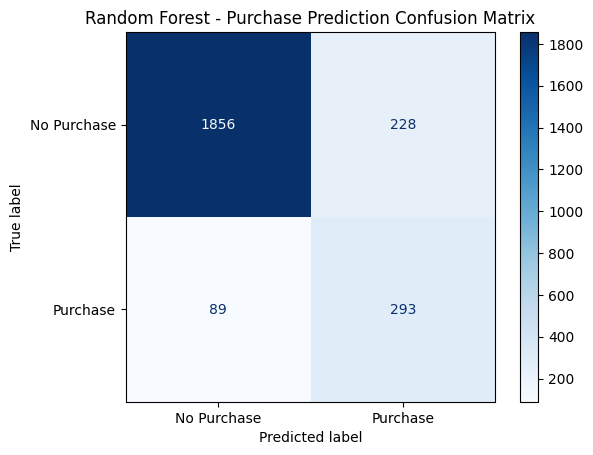

In [16]:
# 1. Generate predictions on the unseen test data
y_pred = rf_model.predict(X_test)

# 2. Print out the formal Classification Report (Precision, Recall, F1-Score)
print("=================== MODEL PERFORMANCE ===================")
print(classification_report(y_test, y_pred))

# 3. Generate and plot a visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(cmap='Blues')

plt.title("Random Forest - Purchase Prediction Confusion Matrix")
plt.show()

C:\Users\Babji\AppData\Local\Temp\ipykernel_7276\3596798826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


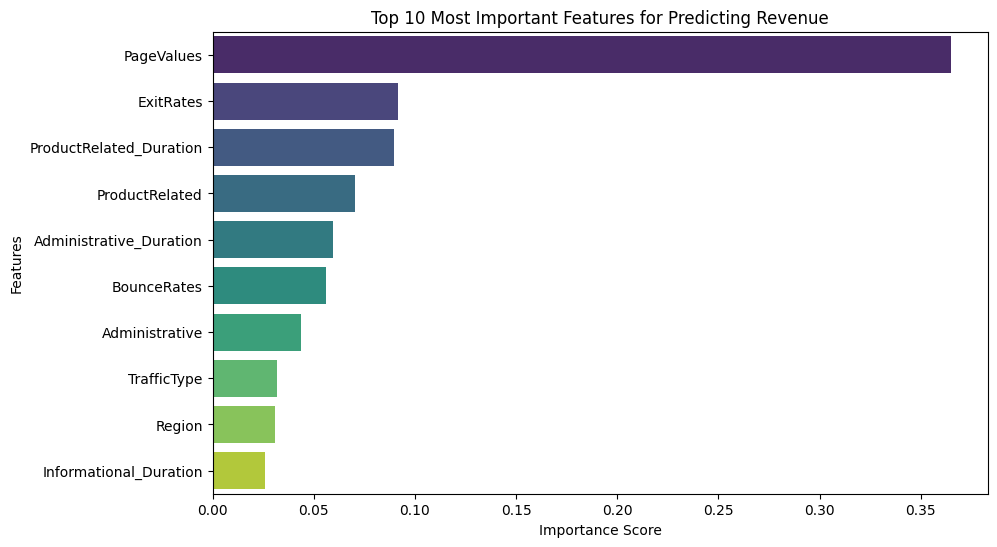

In [ ]:
# Extract feature importances from your trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a clean DataFrame to display them
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Revenue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## OBSERVATION
 * Page values is the strongest feature affecting revenue
 * Most buyers are likely to spend more time on product related pages than administrative (log in /sign) in pages
 * The duration that a potential buyer interacts with on information (about, help) barely affects revenue

## Model Performance Analysis

The model achieved an overall accuracy of 88%, indicating strong general performance. However, given the class imbalance in the dataset (fewer buyers than non-buyers), accuracy alone is not a sufficient metric.

Focusing on the target class (buyers):

- **Recall (0.70)**: The model successfully identifies 70% of actual buyers. This is important from a business perspective, as it ensures that most potential customers are captured.

- **Precision (0.60)**: Out of all predicted buyers, 60% were actual buyers. This indicates that some non-buyers are incorrectly classified as buyers.

- **F1-score (0.65)**: The balance between precision and recall shows that the model performs reasonably well in identifying purchasing behavior.

The model prioritizes recall over precision, which is appropriate in this context. Missing a potential buyer represents a lost business opportunity, whereas incorrectly targeting a non-buyer has a lower cost.

Overall, the model demonstrates a strong ability to detect purchase intent, though there is room for improvement in reducing false positives.

* Before performing cross validation, the recall for buyers was 0.7 while precision was 0.6. 
* After performing cross validation without class balancing, the recall rose to 0.77 and precision fell to 0.56
* cross validation score increased from 86.6 to 87.9 without class imbalance being handled
